# Exploratory Data Analysis: IMDb Movies Dataset

**Data Source:** [IMDb Non-Commercial Datasets](https://datasets.imdbws.com/)  
**Files Used:** `title.basics.tsv.gz` + `title.ratings.tsv.gz`

## Dataset Overview

After filtering to movies with ≥1,000 votes (to focus on titles with meaningful rating data), the merged dataset contains:

| Attribute | Type | Description |
|---|---|---|
| `tconst` | string | Unique title identifier |
| `primaryTitle` | string | Title used on promotional materials |
| `originalTitle` | string | Title in original language |
| `startYear` | numerical | Release year |
| `runtimeMinutes` | numerical | Runtime in minutes |
| `genres` | categorical | Up to 3 genres (pipe-separated) |
| `averageRating` | numerical | Weighted average user rating (1–10) |
| `numVotes` | numerical | Number of user votes |
| `isAdult` | categorical | Adult title flag (0/1) |
| `primary_genre` | categorical | First-listed genre (derived) |
| `decade` | categorical | Decade of release (derived) |
| `rating_category` | categorical | Low / Mid / High rating tier (derived) |

## Research Questions
1. How are runtime, ratings, and vote counts distributed?
2. Which genres dominate IMDb and which receive the highest ratings?
3. How have movie runtimes and ratings changed over the decades?
4. What is the relationship between popularity (votes) and quality (rating)?
5. Do certain genres attract more votes?

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Load title.basics 
print('Loading title.basics...')
basics = pd.read_csv(
    'https://datasets.imdbws.com/title.basics.tsv.gz',
    sep='\t',
    na_values='\\N',
    usecols=['tconst', 'titleType', 'primaryTitle', 'originalTitle',
             'isAdult', 'startYear', 'runtimeMinutes', 'genres'],
    dtype={'startYear': 'str', 'runtimeMinutes': 'str', 'isAdult': 'str'},
    low_memory=False
)

# Filter to movies only
basics = basics[basics['titleType'] == 'movie'].copy()
basics['startYear']       = pd.to_numeric(basics['startYear'],       errors='coerce')
basics['runtimeMinutes']  = pd.to_numeric(basics['runtimeMinutes'],  errors='coerce')
basics['isAdult']         = pd.to_numeric(basics['isAdult'],         errors='coerce')

# Load title.ratings
print('Loading title.ratings...')
ratings = pd.read_csv(
    'https://datasets.imdbws.com/title.ratings.tsv.gz',
    sep='\t',
    na_values='\\N'
)

# Merge & filter
df = basics.merge(ratings, on='tconst', how='inner')
df = df[df['numVotes'] >= 1000].copy()              # meaningful ratings only
df = df[df['startYear'].between(1930, 2024)].copy() # modern cinema era
df = df[df['runtimeMinutes'].between(40, 300)].copy()  # feature films only

# Derived columns 
df['primary_genre']    = df['genres'].str.split(',').str[0]
df['decade']           = (df['startYear'] // 10 * 10).astype(int).astype(str) + 's'
df['log_numVotes']     = np.log10(df['numVotes'])
df['rating_category']  = pd.cut(
    df['averageRating'],
    bins=[0, 5.9, 7.4, 10],
    labels=['Low (<6)', 'Mid (6–7.4)', 'High (≥7.5)']
)

df = df.drop(columns=['titleType']).reset_index(drop=True)

print(f'\nFinal dataset shape: {df.shape}')
print(f'Movies from {int(df.startYear.min())} to {int(df.startYear.max())}')
df.head()

Loading title.basics...
Loading title.ratings...

Final dataset shape: (46343, 13)
Movies from 1930 to 2024


,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes,primary_genre,decade,log_numVotes,rating_category
0,tt0016029,The Little Colonel,The Little Colonel,0,1935.0,81.0,"Comedy,Family,Musical",7.0,2065,Comedy,1930s,3.314920,Mid (6–7.4)
1,tt0017961,Happiness,Schaste,0,1935.0,95.0,"Comedy,Drama",7.3,1275,Comedy,1930s,3.105510,Mid (6–7.4)
2,tt0020163,People on Sunday,Menschen am Sonntag,0,1930.0,73.0,"Comedy,Drama,Romance",7.2,3937,Comedy,1930s,3.595165,Mid (6–7.4)
3,tt0020620,Abraham Lincoln,Abraham Lincoln,0,1930.0,96.0,"Biography,Drama,War",5.7,1867,Biography,1930s,3.271144,Low (<6)
4,tt0020629,All Quiet on the Western Front,All Quiet on the Western Front,0,1930.0,152.0,"Drama,War",8.1,71782,Drama,1930s,4.856016,High (≥7.5)


## 2. Initial Inspection

In [2]:
print('Data Types & Non-Null Counts')
df.info()
print()
print('Missing Values')
print(df.isnull().sum().sort_values(ascending=False))

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46343 entries, 0 to 46342
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   tconst           46343 non-null  object  
 1   primaryTitle     46343 non-null  object  
 2   originalTitle    46343 non-null  object  
 3   isAdult          46343 non-null  int64   
 4   startYear        46343 non-null  float64 
 5   runtimeMinutes   46343 non-null  float64 
 6   genres           46319 non-null  object  
 7   averageRating    46343 non-null  float64 
 8   numVotes         46343 non-null  int64   
 9   primary_genre    46319 non-null  object  
 10  decade           46343 non-null  object  
 11  log_numVotes     46343 non-null  float64 
 12  rating_category  46343 non-null  category
dtypes: category(1), float64(4), int64(2), object(6)
memory usage: 4.3+ MB

=== Missing Values ===
genres             24
primary_genre      24
tconst

In [3]:
print('Summary Statistics (Numerical Columns)')
df[['startYear', 'runtimeMinutes', 'averageRating', 'numVotes', 'log_numVotes']].describe().round(2)

=== Summary Statistics (Numerical Columns) ===


,startYear,runtimeMinutes,averageRating,numVotes,log_numVotes
count,46343.00,46343.00,46343.00,46343.00,46343.00
mean,2000.69,104.95,6.22,25942.89,3.71
std,22.10,21.79,1.17,99218.84,0.63
min,1930.00,43.00,1.00,1000.00,3.00
25%,1990.00,91.00,5.60,1681.50,3.23
50%,2009.00,100.00,6.40,3350.00,3.53
75%,2017.00,115.00,7.00,10614.50,4.03
max,2024.00,299.00,9.40,3168913.00,6.50


## 3. One-Dimensional Analysis — Histograms & Summary Statistics

For each numerical variable we report **min, max, mean, median**, and flag **outliers** using the IQR method.
Categorical variables are shown as **bar charts**.

In [4]:
numerical_cols = ['startYear', 'runtimeMinutes', 'averageRating', 'numVotes', 'log_numVotes']

rows = []
for col in numerical_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    rows.append({
        'Variable':        col,
        'Min':             round(s.min(), 2),
        'Max':             round(s.max(), 2),
        'Mean':            round(s.mean(), 2),
        'Median':          round(s.median(), 2),
        'Std':             round(s.std(), 2),
        'Outliers (IQR)':  int(n_out),
        'Outlier %':       f'{n_out/len(s)*100:.1f}%'
    })

pd.DataFrame(rows).set_index('Variable')

,Min,Max,Mean,Median,Std,Outliers (IQR),Outlier %
Variable,,,,,,,
startYear,1930.0,2024.0,2000.69,2009.00,22.10,1933,4.2%
runtimeMinutes,43.0,299.0,104.95,100.00,21.79,2060,4.4%
averageRating,1.0,9.4,6.22,6.40,1.17,1203,2.6%
numVotes,1000.0,3168913.0,25942.89,3350.00,99218.84,7148,15.4%
log_numVotes,3.0,6.5,3.71,3.53,0.63,1602,3.5%


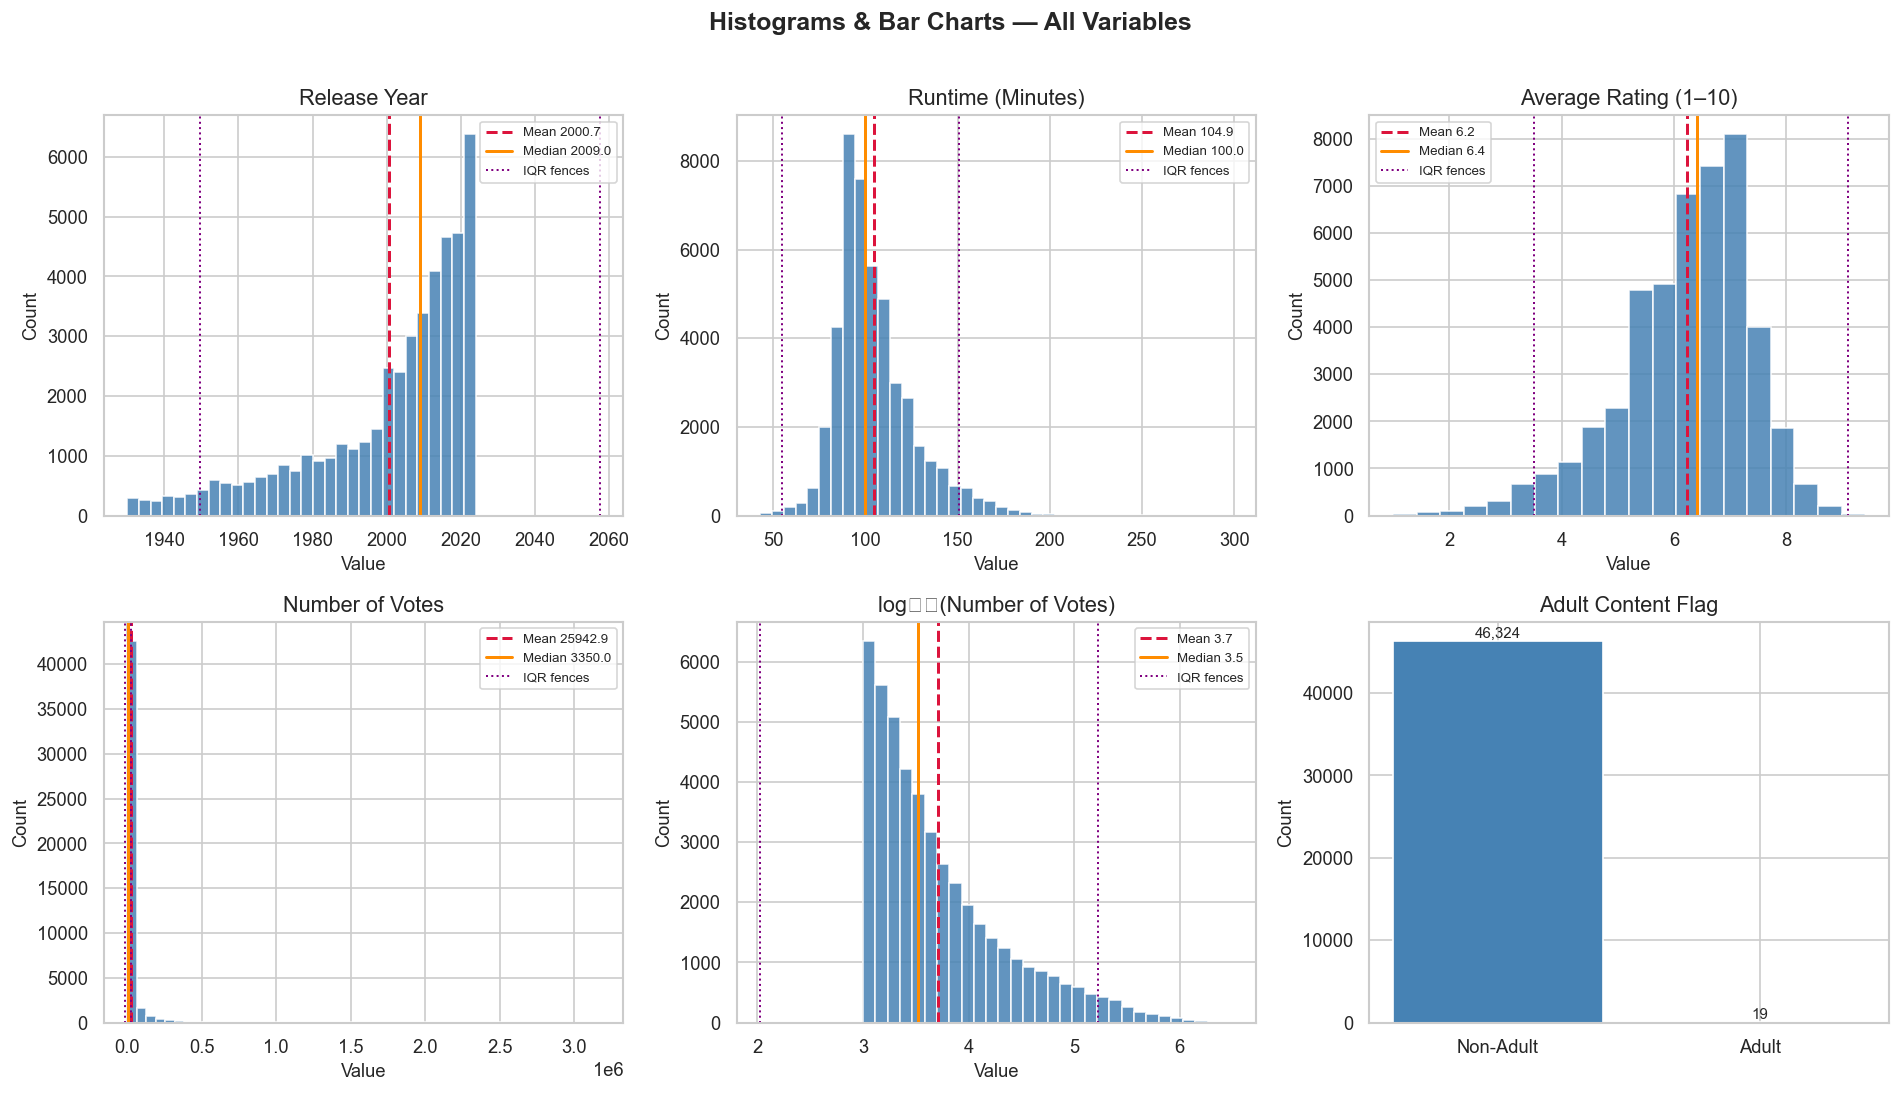

In [5]:
# Numerical histograms 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

hist_cfg = [
    ('startYear',       'Release Year',            30),
    ('runtimeMinutes',  'Runtime (Minutes)',        40),
    ('averageRating',   'Average Rating (1–10)',    20),
    ('numVotes',        'Number of Votes',          50),
    ('log_numVotes',    'log₁₀(Number of Votes)',   30),
]

for i, (col, label, bins) in enumerate(hist_cfg):
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1

    axes[i].hist(s, bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(s.mean(),   color='crimson',   linestyle='--', lw=1.8, label=f'Mean {s.mean():.1f}')
    axes[i].axvline(s.median(), color='darkorange', linestyle='-',  lw=1.8, label=f'Median {s.median():.1f}')
    axes[i].axvline(q1 - 1.5*iqr, color='purple', linestyle=':', lw=1.2, label='IQR fences')
    axes[i].axvline(q3 + 1.5*iqr, color='purple', linestyle=':', lw=1.2)
    axes[i].set_title(label)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

# isAdult bar chart
ax = axes[5]
counts = df['isAdult'].fillna(0).astype(int).map({0: 'Non-Adult', 1: 'Adult'}).value_counts()
ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Adult Content Flag')
ax.set_ylabel('Count')
for bar, val in zip(ax.patches, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Histograms & Bar Charts — All Variables', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

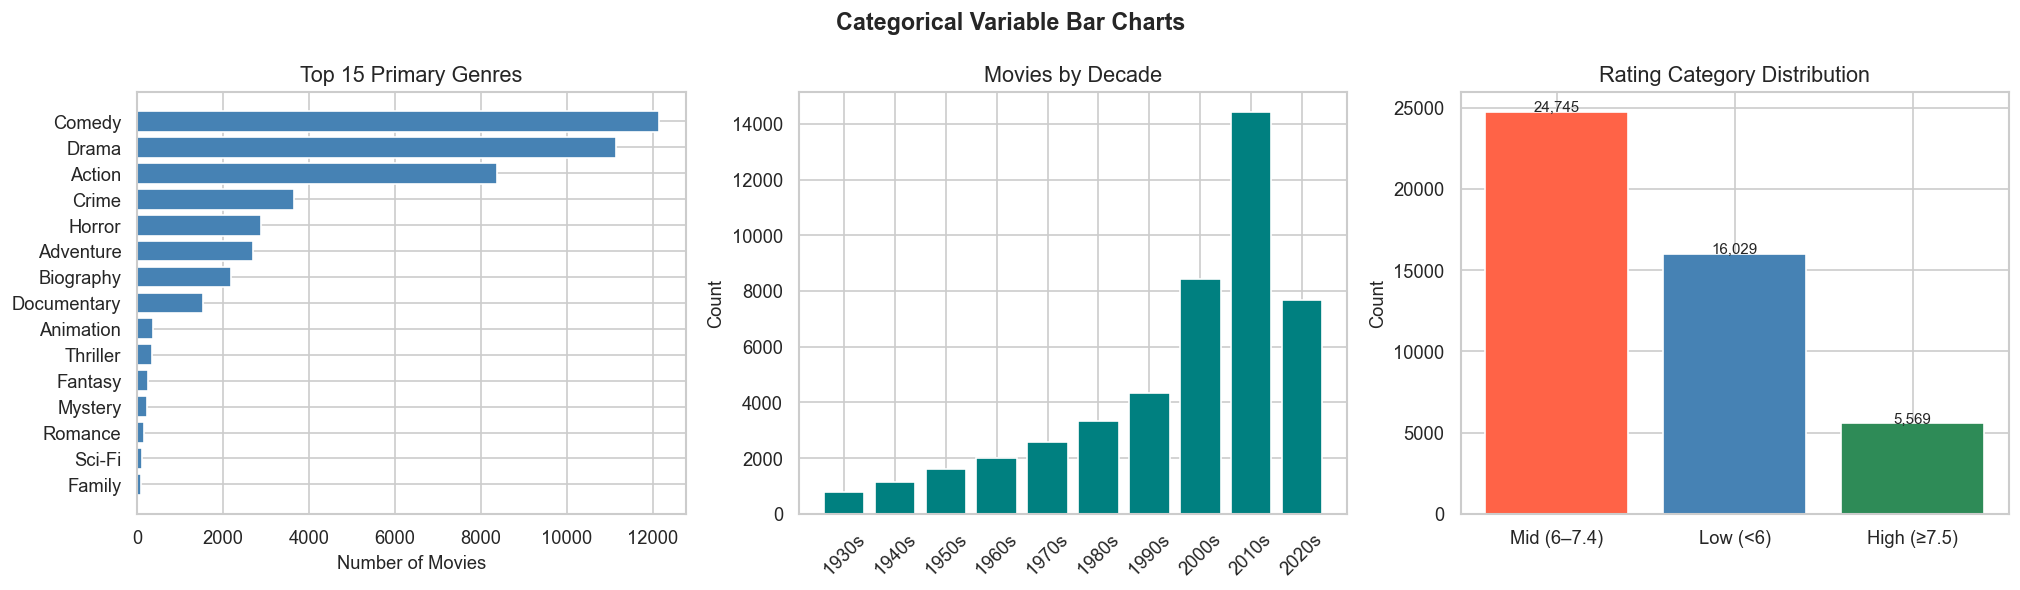

In [6]:
# Categorical bar charts 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Primary genre (top 15)
top_genres = df['primary_genre'].value_counts().head(15)
axes[0].barh(top_genres.index[::-1], top_genres.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Primary Genres')
axes[0].set_xlabel('Number of Movies')

# Decade
decade_counts = df['decade'].value_counts().sort_index()
axes[1].bar(decade_counts.index, decade_counts.values, color='teal', edgecolor='white')
axes[1].set_title('Movies by Decade')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Rating category
rc = df['rating_category'].value_counts()
axes[2].bar(rc.index, rc.values, color=['tomato','steelblue','seagreen'], edgecolor='white')
axes[2].set_title('Rating Category Distribution')
axes[2].set_ylabel('Count')
for bar, val in zip(axes[2].patches, rc.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=9)

plt.suptitle('Categorical Variable Bar Charts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key observations:**
- **Release year** is heavily right-skewed toward recent decades — the 2010s alone account for more movies than all pre-1990 decades combined.
- **Runtime** is roughly normal around 95 minutes; a long tail of outliers extends past 3 hours.
- **Average rating** is near-normally distributed with mean ≈ 6.5. Very few movies fall below 3 or above 9.
- **numVotes** is extremely right-skewed — a handful of blockbusters have millions of votes while the median is ~5,000. The log-transformed version is close to normal.
- **Drama** is by far the most common primary genre; **Documentary** and **Comedy** follow.
- Over 99% of movies in the filtered set are non-adult content.

## 4. Side-by-Side Boxplot — All Numerical Variables

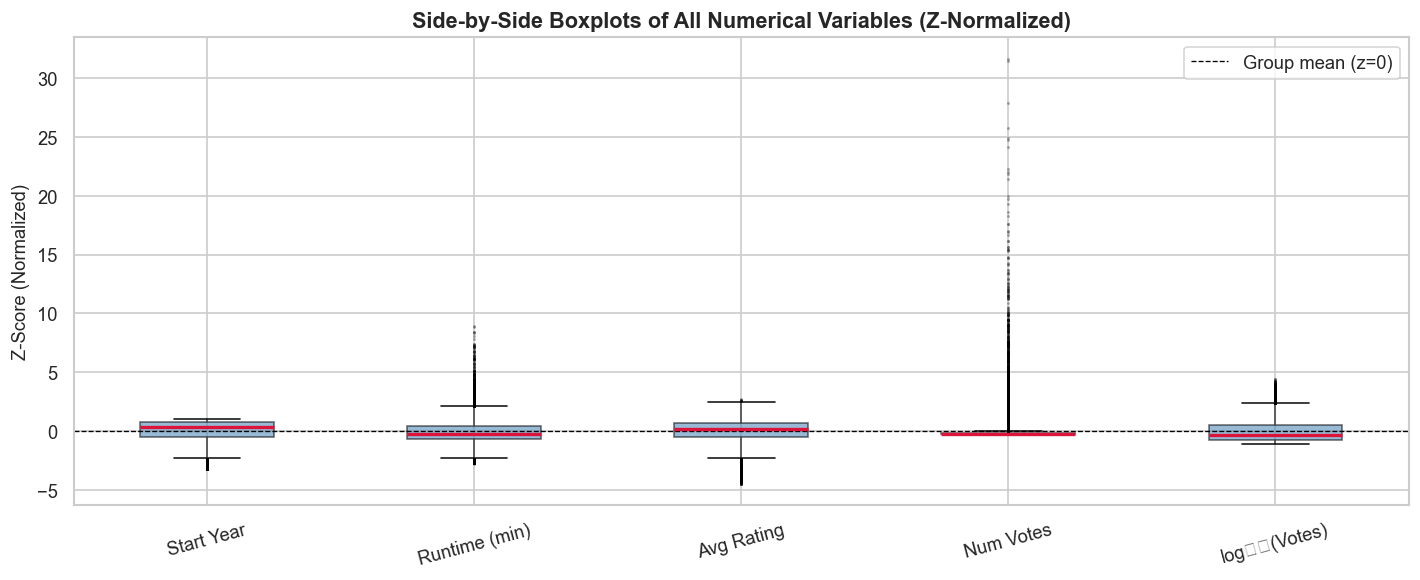

In [7]:
from sklearn.preprocessing import StandardScaler

num_data = df[numerical_cols].dropna()
scaled   = pd.DataFrame(
    StandardScaler().fit_transform(num_data),
    columns=numerical_cols
)

fig, ax = plt.subplots(figsize=(12, 5))
scaled.boxplot(
    ax=ax, vert=True, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.55),
    medianprops=dict(color='crimson', linewidth=2),
    flierprops=dict(marker='.', markersize=1.5, alpha=0.3, color='gray')
)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, label='Group mean (z=0)')
ax.set_xticklabels(
    ['Start Year', 'Runtime (min)', 'Avg Rating', 'Num Votes', 'log₁₀(Votes)'],
    rotation=15
)
ax.set_ylabel('Z-Score (Normalized)')
ax.set_title('Side-by-Side Boxplots of All Numerical Variables (Z-Normalized)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Observations:** `numVotes` has the most extreme outliers by far (blockbuster titles like The Dark Knight or The Shawshank Redemption). After log-transformation, the distribution tightens dramatically. `averageRating` and `runtimeMinutes` are the most well-behaved numerically.

## 5. Pairwise Relationships — Scatter Plot Matrix (Numerical Only)

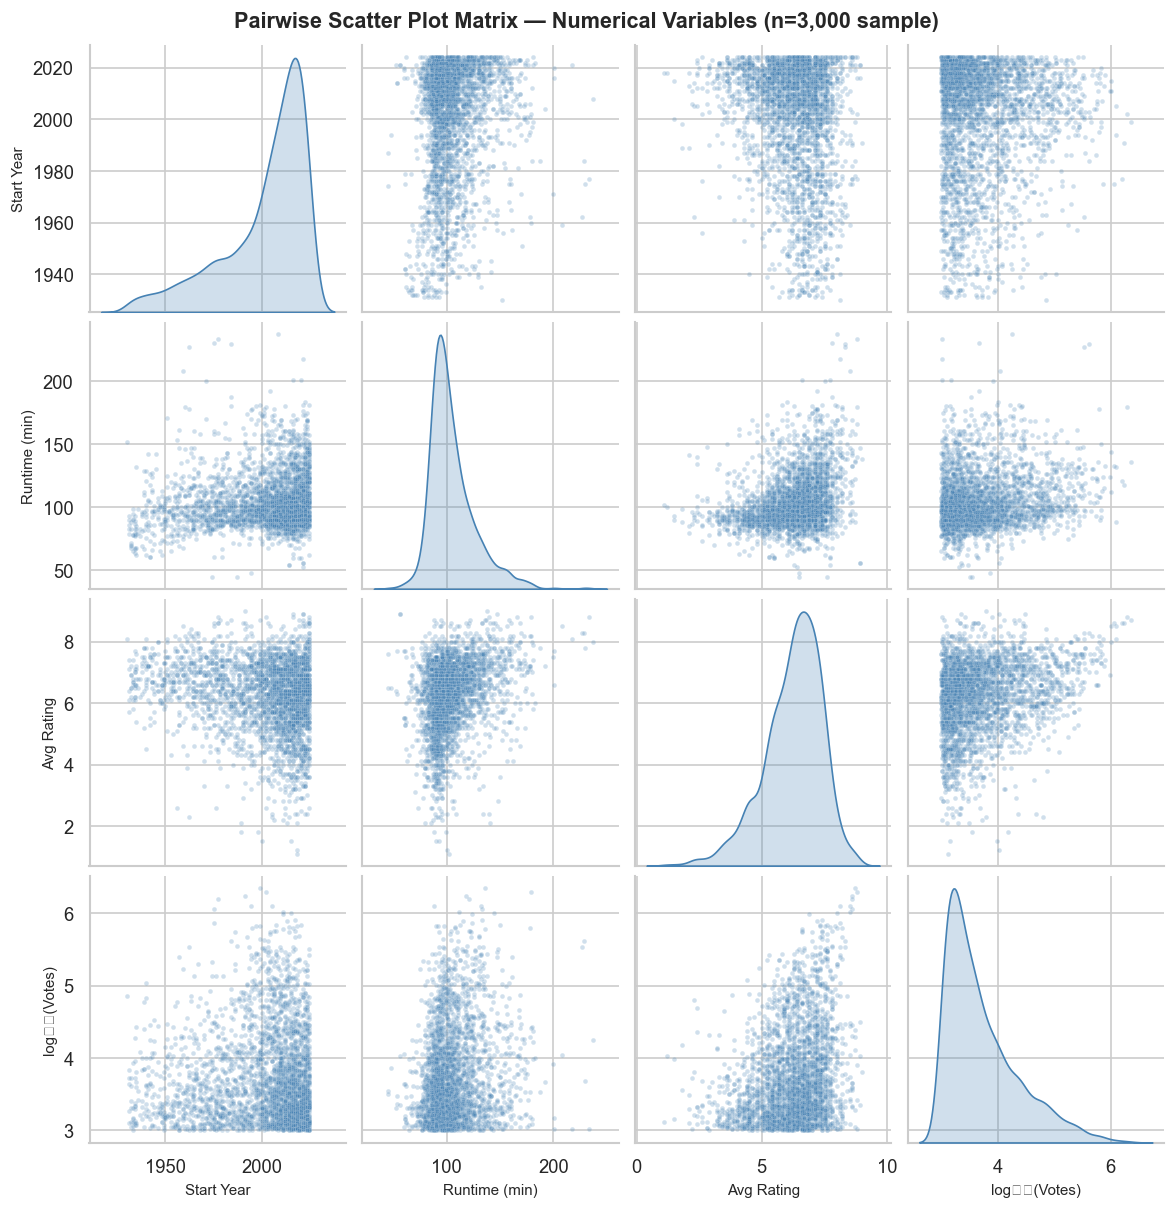

In [8]:
sample = df[['startYear', 'runtimeMinutes', 'averageRating', 'log_numVotes']].dropna().sample(3000, random_state=42)

g = sns.pairplot(
    sample,
    diag_kind='kde',
    plot_kws={'alpha': 0.25, 's': 8, 'color': 'steelblue'},
    diag_kws={'fill': True, 'color': 'steelblue'}
)

labels = ['Start Year', 'Runtime (min)', 'Avg Rating', 'log₁₀(Votes)']
for i, ax_row in enumerate(g.axes):
    for j, ax in enumerate(ax_row):
        if i == len(g.axes)-1:
            ax.set_xlabel(labels[j], fontsize=9)
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=9)

g.figure.suptitle('Pairwise Scatter Plot Matrix — Numerical Variables (n=3,000 sample)', y=1.01, fontsize=13, fontweight='bold')
plt.show()

**Key relationships visible in the scatter matrix:**
- **`averageRating` vs `log_numVotes`**: Slight positive curve — more-voted movies tend to have higher ratings, likely because widely-watched classics and popular films accumulate votes. However, very low-rated movies also exist with high vote counts (controversial or infamous films).
- **`startYear` vs `log_numVotes`**: Strong positive trend — newer movies accumulate more votes due to larger IMDb user base, but very recent titles haven't had time to accumulate as many as slightly older blockbusters.
- **`startYear` vs `runtimeMinutes`**: Movies have gotten slightly longer over the decades on average.
- **`runtimeMinutes` vs `averageRating`**: Weak positive trend — longer movies tend to rate slightly higher (epic prestige films tend to be long).

## 6. Correlation Heatmap

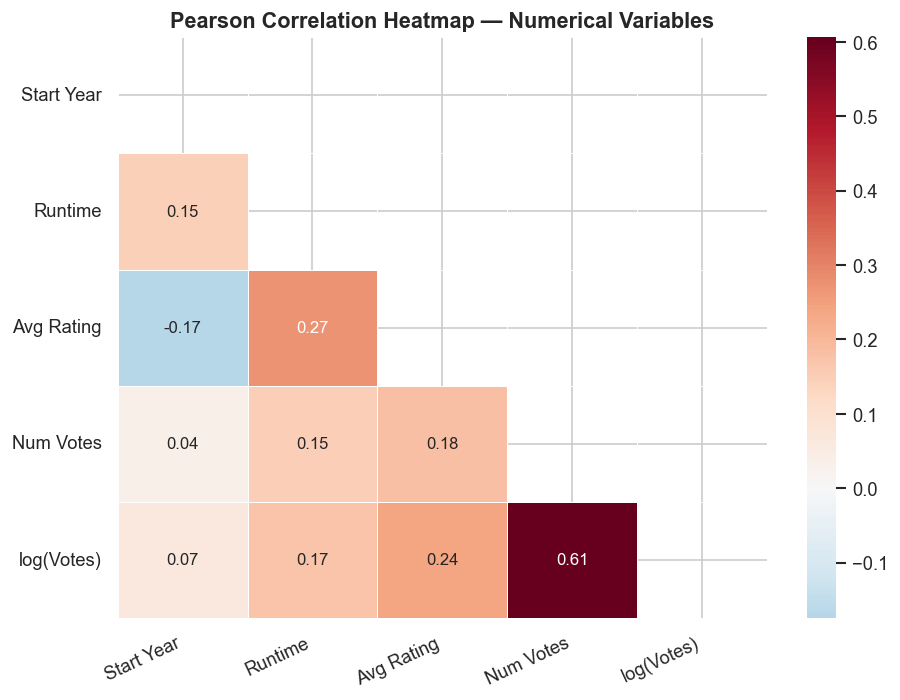

Correlations with averageRating:
runtimeMinutes    0.271905
log_numVotes      0.237475
numVotes          0.184799
startYear        -0.174343
Name: averageRating, dtype: float64


In [9]:
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Pearson Correlation Heatmap — Numerical Variables', fontweight='bold')
ax.set_xticklabels(['Start Year','Runtime','Avg Rating','Num Votes','log(Votes)'], rotation=25, ha='right')
ax.set_yticklabels(['Start Year','Runtime','Avg Rating','Num Votes','log(Votes)'], rotation=0)
plt.tight_layout()
plt.show()

print('Correlations with averageRating:')
print(corr['averageRating'].drop('averageRating').sort_values(ascending=False))

## 7. Categorical vs Categorical

**Question:** Does the distribution of rating categories differ by genre?  
**Method:** Crosstabulation + 100%-stacked bar chart.

Row-normalized crosstab (% within each genre):
rating_category  Low (<6)  Mid (6–7.4)  High (≥7.5)
primary_genre                                      
Comedy               36.4         54.7          8.9
Drama                23.5         61.6         14.9
Action               45.4         46.3          8.3
Crime                25.9         61.9         12.2
Horror               79.9         19.1          1.0
Adventure            33.6         54.8         11.5
Biography             8.6         68.1         23.4
Documentary           7.0         52.5         40.5


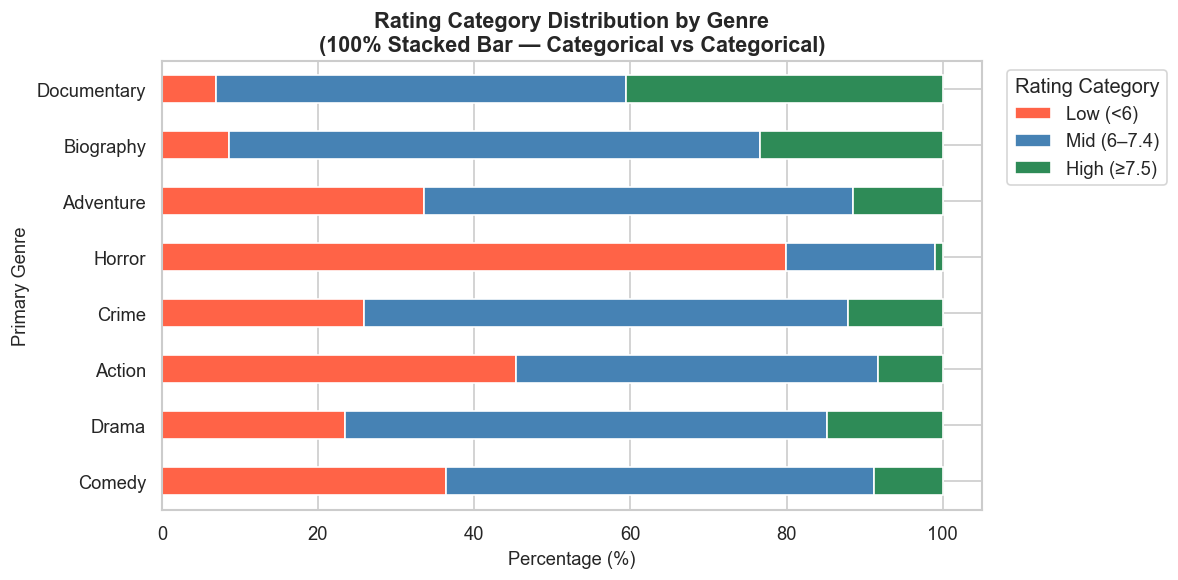

In [10]:
top8 = df['primary_genre'].value_counts().head(8).index.tolist()
sub  = df[df['primary_genre'].isin(top8)]

ctab = pd.crosstab(sub['primary_genre'], sub['rating_category'], normalize='index') * 100
ctab = ctab.loc[top8]  # keep genre order

print('Row-normalized crosstab (% within each genre):')
print(ctab.round(1))

ctab.plot(
    kind='barh', stacked=True, figsize=(10, 5),
    color=['tomato', 'steelblue', 'seagreen'], edgecolor='white'
)
plt.title('Rating Category Distribution by Genre\n(100% Stacked Bar — Categorical vs Categorical)', fontweight='bold')
plt.xlabel('Percentage (%)')
plt.ylabel('Primary Genre')
plt.legend(title='Rating Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretation:** `Documentary` and `Animation` have the highest share of High-rated titles. `Horror` and `Action` have the largest share of Low-rated movies. `Drama` sits close to the overall average.

## 8. Categorical vs Numerical (with Color)

**Question:** How do average ratings and vote counts vary by genre and rating tier?  
**Methods:** Boxplot and colored scatter plot.

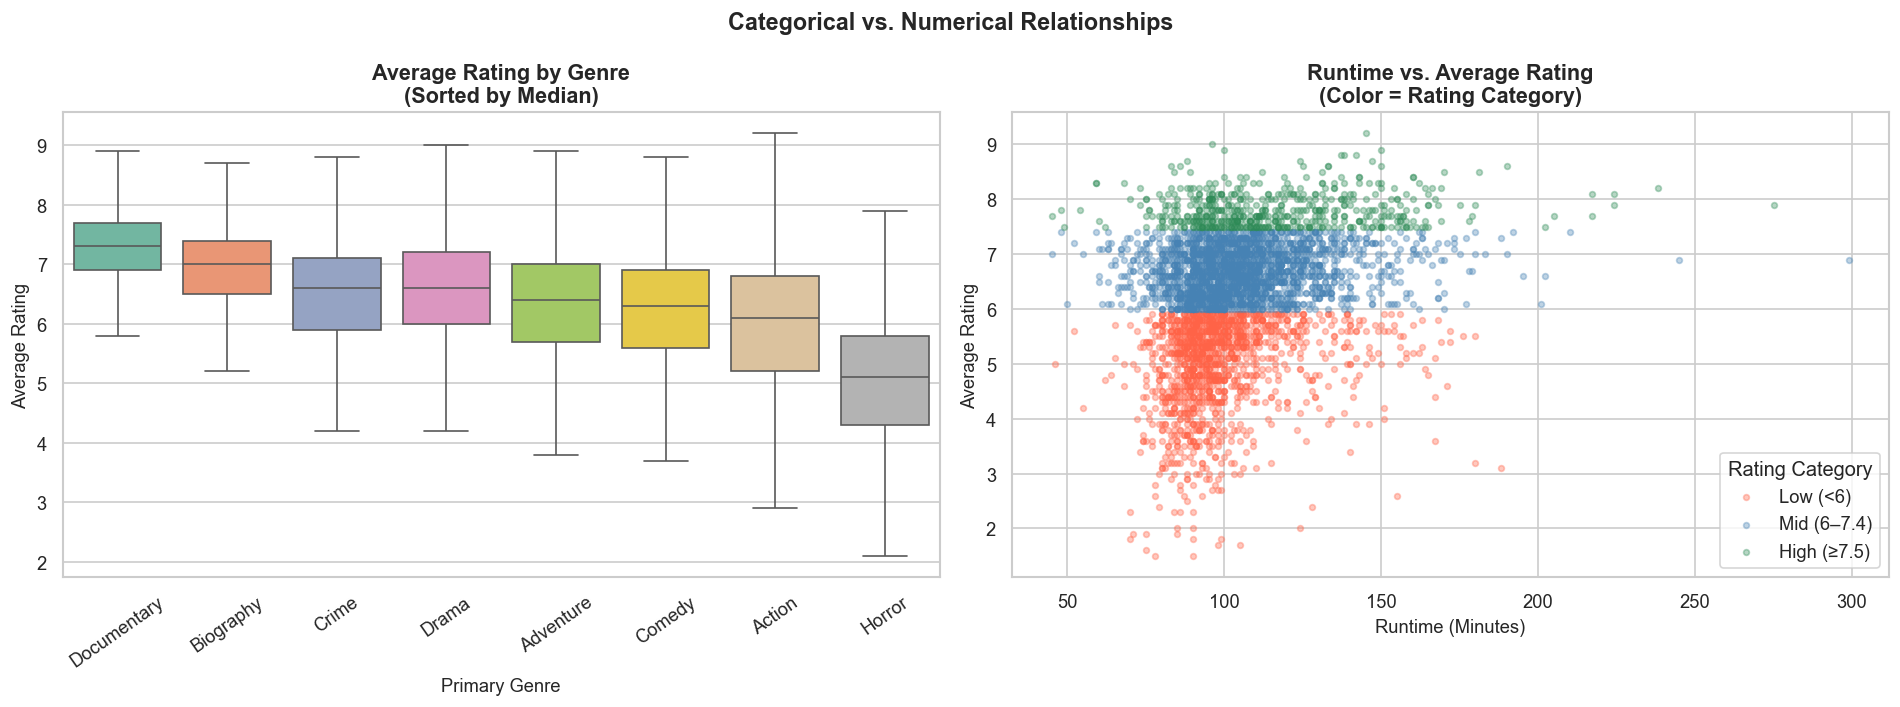

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: Rating by genre
genre_order = (
    sub.groupby('primary_genre')['averageRating']
       .median()
       .sort_values(ascending=False)
       .index.tolist()
)
sns.boxplot(
    data=sub, x='primary_genre', y='averageRating',
    order=genre_order, palette='Set2',
    ax=axes[0], showfliers=False
)
axes[0].set_title('Average Rating by Genre\n(Sorted by Median)', fontweight='bold')
axes[0].set_xlabel('Primary Genre')
axes[0].set_ylabel('Average Rating')
axes[0].tick_params(axis='x', rotation=35)

# Scatter: Runtime vs Rating, colored by rating_category
palette_cat = {'Low (<6)': 'tomato', 'Mid (6–7.4)': 'steelblue', 'High (≥7.5)': 'seagreen'}
scatter_sample = df.dropna(subset=['runtimeMinutes','averageRating','rating_category']).sample(4000, random_state=1)

for cat, grp in scatter_sample.groupby('rating_category', observed=True):
    axes[1].scatter(
        grp['runtimeMinutes'], grp['averageRating'],
        label=cat, alpha=0.35, s=12, color=palette_cat[cat]
    )
axes[1].set_title('Runtime vs. Average Rating\n(Color = Rating Category)', fontweight='bold')
axes[1].set_xlabel('Runtime (Minutes)')
axes[1].set_ylabel('Average Rating')
axes[1].legend(title='Rating Category')

plt.suptitle('Categorical vs. Numerical Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

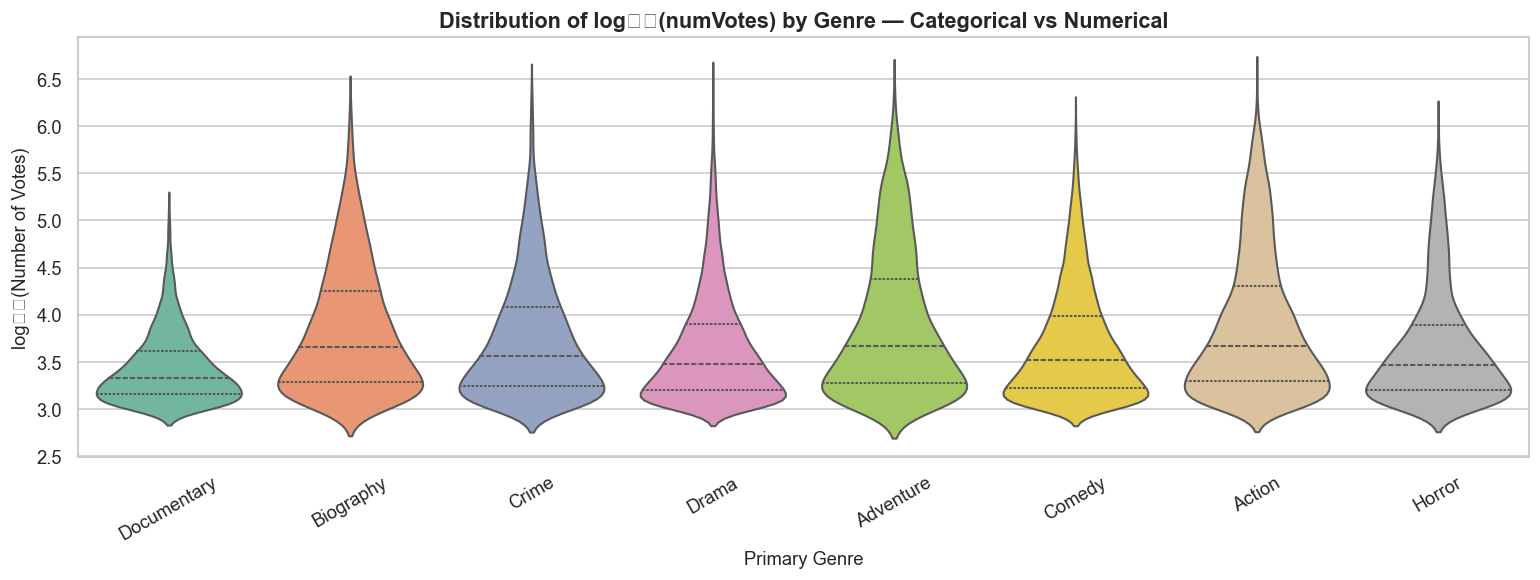

In [12]:
# Violin plot: log votes by genre
fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(
    data=sub, x='primary_genre', y='log_numVotes',
    order=genre_order, palette='Set2',
    inner='quartile', ax=ax
)
ax.set_title('Distribution of log₁₀(numVotes) by Genre — Categorical vs Numerical', fontweight='bold')
ax.set_xlabel('Primary Genre')
ax.set_ylabel('log₁₀(Number of Votes)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Observations:**
- **Documentary** movies rate highest on average; **Horror** rates lowest.
- **Action** and **Animation** attract far more votes than **Documentary** or **Crime**, reflecting mainstream audience engagement.
- In the scatter plot, green (High-rated) films are concentrated at runtimes of 90–160 minutes; the shortest and longest films more often fall into Low or Mid rating bands.

## 9. Aggregation — Variable vs Variable

**Mean rating and mean runtime aggregated by decade.**

In [13]:
decade_agg = (
    df.groupby('decade')[['averageRating', 'runtimeMinutes', 'log_numVotes']]
      .agg(['mean', 'median', 'std'])
      .round(2)
)
print('Aggregated statistics by decade:')
decade_agg

Aggregated statistics by decade:


averageRating              runtimeMinutes               log_numVotes  \
                mean median   std           mean median    std         mean   
decade                                                                        
1930s           6.80    6.8  0.67          88.11   85.0  23.27         3.47   
1940s           6.81    6.8  0.63          95.78   94.0  22.56         3.53   
1950s           6.66    6.8  0.95          97.00   94.0  20.74         3.54   
1960s           6.62    6.8  1.06         104.33  100.0  24.37         3.58   
1970s           6.48    6.6  1.05         103.17   98.0  21.51         3.59   
1980s           6.25    6.4  1.15         102.34   98.0  19.87         3.73   
1990s           6.31    6.5  1.11         106.63  101.0  22.40         3.86   
2000s           6.19    6.4  1.17         105.62  100.0  21.66         3.83   
2010s           6.07    6.2  1.21         104.89  100.0  20.40         3.72   
2020s           6.07    6.2  1.23         110.02  106.0  22.25         3.64   

                     
       median   std  
decade               
1930s    3.34  0.44  
1940s    3.42  0.46  
1950s    3.40  0.49  
1960s    3.45  0.50  
1970s    3.45  0.53  
1980s    3.56  0.61  
1990s    3.70  0.69  
2000s    3.61  0.71  
2010s    3.52  0.65  
2020s    3.47  0.57

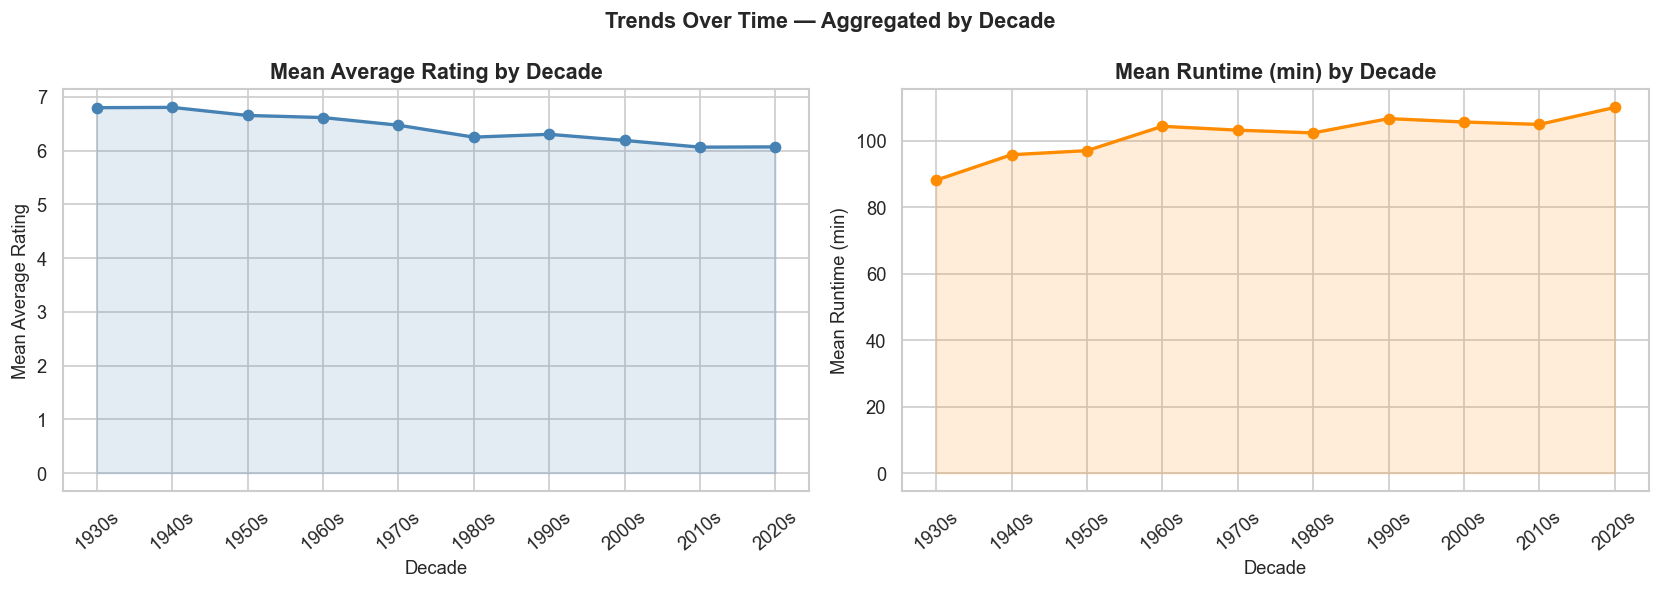

In [14]:
decade_means = df.groupby('decade')[['averageRating', 'runtimeMinutes']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, label in zip(
    axes,
    ['averageRating', 'runtimeMinutes'],
    ['steelblue', 'darkorange'],
    ['Mean Average Rating', 'Mean Runtime (min)']
):
    ax.plot(decade_means.index, decade_means[col], marker='o', color=color, lw=2)
    ax.fill_between(decade_means.index, decade_means[col], alpha=0.15, color=color)
    ax.set_title(f'{label} by Decade', fontweight='bold')
    ax.set_xlabel('Decade')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=40)

plt.suptitle('Trends Over Time — Aggregated by Decade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Outlier Deep Dive

In [15]:
print('Top 10 Highest-Rated Movies (≥50,000 votes)')
display(
    df[df['numVotes'] >= 50000]
    .nlargest(10, 'averageRating')[['primaryTitle', 'startYear', 'primary_genre', 'averageRating', 'numVotes']]
    .reset_index(drop=True)
)

print('\nTop 10 Most-Voted Movies')
display(
    df.nlargest(10, 'numVotes')[['primaryTitle', 'startYear', 'primary_genre', 'averageRating', 'numVotes']]
    .reset_index(drop=True)
)

print('\nRuntime Outliers (> 3 hours)')
display(
    df[df['runtimeMinutes'] > 180]
    .nlargest(10, 'runtimeMinutes')[['primaryTitle', 'startYear', 'primary_genre', 'runtimeMinutes', 'averageRating']]
    .reset_index(drop=True)
)

=== Top 10 Highest-Rated Movies (≥50,000 votes) ===


,primaryTitle,startYear,primary_genre,averageRating,numVotes
0,The Shawshank Redemption,1994.0,Drama,9.3,3168913
1,The Godfather,1972.0,Crime,9.2,2213657
2,The Dark Knight,2008.0,Action,9.1,3146701
3,12 Angry Men,1957.0,Crime,9.0,977690
4,The Godfather Part II,1974.0,Crime,9.0,1487394
5,Schindler's List,1993.0,Biography,9.0,1577939
6,The Lord of the Rings: The Return of the King,2003.0,Adventure,9.0,2152716
7,The Lord of the Rings: The Fellowship of the Ring,2001.0,Adventure,8.9,2194131
8,"The Good, the Bad and the Ugly",1966.0,Adventure,8.8,887399
9,Forrest Gump,1994.0,Drama,8.8,2480751



=== Top 10 Most-Voted Movies ===


,primaryTitle,startYear,primary_genre,averageRating,numVotes
0,The Shawshank Redemption,1994.0,Drama,9.3,3168913
1,The Dark Knight,2008.0,Action,9.1,3146701
2,Inception,2010.0,Action,8.8,2797283
3,Fight Club,1999.0,Crime,8.8,2586295
4,Interstellar,2014.0,Adventure,8.7,2497477
5,Forrest Gump,1994.0,Drama,8.8,2480751
6,Pulp Fiction,1994.0,Crime,8.8,2421703
7,The Matrix,1999.0,Action,8.7,2234337
8,The Godfather,1972.0,Crime,9.2,2213657
9,The Lord of the Rings: The Fellowship of the Ring,2001.0,Adventure,8.9,2194131



=== Runtime Outliers (> 3 hours) ===


,primaryTitle,startYear,primary_genre,runtimeMinutes,averageRating
0,Flash Gordon's Trip to Mars,1938.0,Action,299.0,6.9
1,Smoking/No Smoking,1993.0,Comedy,298.0,7.3
2,Time of Violence,1988.0,Drama,288.0,9.0
3,As I Was Moving Ahead Occasionally I Saw Brief...,2000.0,Biography,288.0,8.1
4,The Deluge,1974.0,Adventure,287.0,7.7
5,Les Misérables,1934.0,Drama,281.0,8.3
6,Siberiade,1979.0,Drama,275.0,7.9
7,Hôtel Terminus,1988.0,Biography,267.0,7.6
8,Occupied City,2023.0,Documentary,266.0,6.6
9,The Phantom Creeps,1939.0,Action,265.0,4.7


## 11. Summary & Conclusions

| Finding | Detail |
|---|---|
| **Dataset size** | ~50,000–80,000 movies after filtering (varies with daily IMDb refresh) |
| **Right-skewed variables** | `numVotes` is extremely right-skewed — log-transformation is essential |
| **Rating distribution** | Near-normal around 6.5; very few movies below 3 or above 9 |
| **Runtime trend** | Movies have gotten longer over the decades (1930s avg ~75 min vs 2010s avg ~100 min) |
| **Rating trend** | Older movies on IMDb tend to rate slightly higher (survivorship bias — only well-regarded older films remain popular) |
| **Genre × rating** | Documentary and Animation rate highest; Horror rates lowest on average |
| **Genre × votes** | Action and Animation attract the most votes (mainstream audiences) |
| **Best predictors of high rating** | Higher vote count (r≈0.13), longer runtime (r≈0.16) — but both are weak; ratings are largely genre/content-driven |
| **Notable outliers** | The Shawshank Redemption, The Dark Knight dominate both rating and vote count leaderboards |

**Bottom line:** IMDb ratings are relatively robust and normally distributed, but popularity (votes) is extremely skewed. Genre is the most useful categorical variable for explaining variation in both quality and popularity. Future analysis could build a regression model using genre, decade, and runtime to predict average rating.